# Predição de Gênero - Análise de Reviews

- **Aluno:** Pedro Yutaro Mont Morency Nakamura  
- **Data:** 17/05/2026
- **Objetivo:** Estabelecer a fundamentação científica e estatística do projeto. Este notebook deve validar as hipóteses que guiarão a engenharia de atributos de todo o sistema.

---

# 0. Configurações e Importações de Dependências e Dados

In [1]:
import pandas as pd
import numpy as np

# Visualização de Dados
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Pré-Processamento
import re
from sklearn.feature_extraction.text import CountVectorizer
import spacy

# Estruturas e estatística
import nltk
from nltk.corpus import stopwords
from scipy.stats import mannwhitneyu

## 0.1 Configuração de Gráficos

In [2]:
# Configurações de visualização
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
cores_genero = {'M': '#1f77b4', 'F': '#e377c2'} # Azul para Masculino, Rosa/Roxo para Feminino

## 0.2 Carregamento do modelo SpaCy para Português

In [3]:
try:
    # Carrega apenas componentes necessarios para POS/lemmas.
    disable=["parser", "ner"]
    nlp = spacy.load("pt_core_news_lg", disable=disable)
    print("✅ SpaCy pt_core_news_lg carregado com sucesso!")
except Exception as e:
    print(f"❌ Erro ao carregar o modelo: {e}")

✅ SpaCy pt_core_news_lg carregado com sucesso!


## 0.3 Importação dos Datasets

In [4]:
# Caminhos para os dados
TRAIN_PATH = '../data/treino.csv'
VALIDATION_PATH = '../data/validacao.csv'

In [5]:
# Carregando CSVs
df_train = pd.read_csv(TRAIN_PATH, encoding='utf-8', low_memory=False)
df_val = pd.read_csv(VALIDATION_PATH, encoding='utf-8', low_memory=False)

---

# 1. Exploração dos Dados

In [7]:
print(f"Treino: {len(df_train)} reviews")
print(f"Distribuição de gênero:\n{df_train['reviewer_gender'].value_counts()}")
df_train.head(3)

Treino: 76942 reviews
Distribuição de gênero:
reviewer_gender
M    39699
F    37243
Name: count, dtype: int64


,submission_date,reviewer_id,product_id,product_name,product_brand,site_category_lv1,site_category_lv2,review_title,overall_rating,recommend_to_a_friend,review_text,reviewer_birth_year,reviewer_gender,reviewer_state
0,2018-01-25 15:09:27,a06d0380bcd447431774739131312d3532e1018988da8c...,129610281,"iPhone 7 Plus 128GB dourado Tela Retina HD 5,5...",apple,Celulares e Smartphones,Smartphone,Iphone,3,Yes,É Verdade Mesmo Gente Essa Promocao? To queren...,1994.0,F,BA
1,2018-05-14 16:20:25,62bbbab0822b6917233e8a9846dc3e7acbdfe6b4df788a...,120934895,"TV LED 32"" Sony KDL-32R305B HD com Conversor D...",sony,TV e Home Theater,TV,Marca conceituada,3,Yes,"Acredito ser uma Boa TV, não tenho como ava...",1965.0,M,BA
2,2018-05-19 15:43:40,27908d4eea73f655ca4d50adc1c373efccc3b748d4a779...,15844032,Suporte P/ Notebook C/ Cooler Gamer Warrior - ...,NaN,Informática e Acessórios,Peças para Notebook,Excelente aquisição,5,Yes,A compra do produto confirmou a qualidade de o...,1951.0,M,PE


In [10]:
df_train[['review_title', 'review_text', 'reviewer_gender']].head(10)

,review_title,review_text,reviewer_gender
0,Iphone,É Verdade Mesmo Gente Essa Promocao? To queren...,F
1,Marca conceituada,"Acredito ser uma Boa TV, não tenho como ava...",M
2,Excelente aquisição,A compra do produto confirmou a qualidade de o...,M
3,Atende as necessidades,Celular intermediário de bom custo benefício. ...,F
4,Muito bom,"Prática, fácil de limpar, excelente produto. R...",F
5,Não comprem. Péssimo produto. Estou totalmente...,"Comprei esse notebook Dell core i7 5567, pensa...",M
6,Enganador,Não compre! Produto colocado à venda engana o ...,M
7,Muito bom,Eu recomendo produto otimo Amei Chegou antes...,F
8,zenfone4max,a memória interna dele é 16 gb mais o sistema ...,M
9,Avaliação do Apresentador de Sildes Laser Powe...,Excelente produto! Indico o produto para qualq...,F


In [135]:
print(f"Validação: {len(df_val)} reviews")
print(f"Distribuição de gênero:\n{df_val['reviewer_gender'].value_counts()}")
df_val.head(3)

Validação: 25647 reviews
Distribuição de gênero:
reviewer_gender
M    13233
F    12414
Name: count, dtype: int64


,submission_date,reviewer_id,product_id,product_name,product_brand,site_category_lv1,site_category_lv2,review_title,overall_rating,recommend_to_a_friend,review_text,reviewer_birth_year,reviewer_gender,reviewer_state
0,2018-04-30 19:24:28,fabc81c4fa9efa6867a78d82ce2713099ed1eea5df9d80...,31575567,Vela Led Decorativa 15cm Pilha Amarelo-Der/07-...,NaN,Decoração,Luminária,Efeito bonito,4,Yes,Gostei do efeito. Parece uma vela de verdade. ...,1954.0,F,RS
1,2018-04-27 17:48:48,6fbac43a75fd2dbb7e74687472779b74cc9602a566be74...,132474081,Smartphone Moto G 5S Dual Chip Android 7.0 Tel...,NaN,Celulares e Smartphones,Smartphone,"Hardware fraco, mas conjunto excelente.",4,Yes,Não me arrependo de ter comprado o G5S à conco...,1996.0,M,RJ
2,2018-03-06 18:45:17,e85bcc86d48fdd1462bada4d5f4f19cde9f86acf157992...,16215756,Cadeira Amanda Medalhao Marrom Rivatti,NaN,Móveis,Cadeira,Excelente qualidade,5,Yes,"Produto recebido dentro do prazo, acondicionad...",1973.0,F,SP


## 1.1 Contagem de valores e tipos

In [136]:
print('\n<===== TRAIN DATAFRAME =====>')
df_train.info()


<===== TRAIN DATAFRAME =====>
<class 'pandas.DataFrame'>
RangeIndex: 76942 entries, 0 to 76941
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   submission_date        76942 non-null  str    
 1   reviewer_id            76942 non-null  str    
 2   product_id             76942 non-null  str    
 3   product_name           76903 non-null  str    
 4   product_brand          24162 non-null  str    
 5   site_category_lv1      76942 non-null  str    
 6   site_category_lv2      74687 non-null  str    
 7   review_title           76776 non-null  str    
 8   overall_rating         76942 non-null  int64  
 9   recommend_to_a_friend  76932 non-null  str    
 10  review_text            75056 non-null  str    
 11  reviewer_birth_year    75753 non-null  float64
 12  reviewer_gender        76942 non-null  str    
 13  reviewer_state         76942 non-null  str    
dtypes: float64(1), int64(1), str(12)
m

In [137]:
print('\n<===== VALIDATION DATAFRAME =====>')
df_val.info()


<===== VALIDATION DATAFRAME =====>
<class 'pandas.DataFrame'>
RangeIndex: 25647 entries, 0 to 25646
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   submission_date        25647 non-null  str    
 1   reviewer_id            25647 non-null  str    
 2   product_id             25647 non-null  int64  
 3   product_name           25629 non-null  str    
 4   product_brand          8048 non-null   str    
 5   site_category_lv1      25645 non-null  str    
 6   site_category_lv2      24875 non-null  str    
 7   review_title           25598 non-null  str    
 8   overall_rating         25647 non-null  int64  
 9   recommend_to_a_friend  25646 non-null  str    
 10  review_text            25044 non-null  str    
 11  reviewer_birth_year    25242 non-null  float64
 12  reviewer_gender        25647 non-null  str    
 13  reviewer_state         25647 non-null  str    
dtypes: float64(1), int64(2), str(

## 1.2 Verificando Valores Nulos

In [138]:
print('<===== TRAIN DATAFRAME =====>')
df_train.isna().sum()

<===== TRAIN DATAFRAME =====>


submission_date              0
reviewer_id                  0
product_id                   0
product_name                39
product_brand            52780
site_category_lv1            0
site_category_lv2         2255
review_title               166
overall_rating               0
recommend_to_a_friend       10
review_text               1886
reviewer_birth_year       1189
reviewer_gender              0
reviewer_state               0
dtype: int64

In [139]:
print('<===== VALIDATION DATAFRAME =====>')
df_val.isna().sum()

<===== VALIDATION DATAFRAME =====>


submission_date              0
reviewer_id                  0
product_id                   0
product_name                18
product_brand            17599
site_category_lv1            2
site_category_lv2          772
review_title                49
overall_rating               0
recommend_to_a_friend        1
review_text                603
reviewer_birth_year        405
reviewer_gender              0
reviewer_state               0
dtype: int64

## 1.3 Análise Preliminar:

Como é possível notar, em ambos os datasets há a presença de valores nulos referente ao conteúdo textual (text e title) das reviews, principalmente nas colunas referentes a marca, categoria e data de nascimento (idade) dos sujeitos.

Registros sem conteúdo textual devem ser removidos e os demais campos tratados de forma adequada.

---

# 2. Perguntas Norteadoras e Preparação para Análise:
#### - Q1: A marca do produto (mesmo sendo apenas 32% presente no dataset), possui alguma correlação com o gênero do reviwer?
#### - Q2: Gênero vs. Categorias (site_category_lv1): Existem categorias de produtos onde um gênero comenta mais que o outro? (Ex: Maquiagem vs. Ferramentas)
#### - Q3: Gênero vs. Avaliação (overall_rating): Homens ou mulheres tendem a ser mais críticos ou elogiosos nas estrelas?.
#### - Q4: Existe uma diferença estatisticamente relevante no tamanho das mensagens escritas por homens e mulheres?.
#### - Q5: Existe um gênero que tende a recomendar o produto mesmo dando notas baixas (3 ou 4)?
#### - Q6: O uso de múltiplas exclamações (ex: "Amei!!!"), letras repetidas ("Linnnnndo") ou textos em "caixa-alta" é mais frequente em qual gênero?
#### - Q7: Há variação no volume de reviews entre janeiro e maio de 2018 para cada gênero? (ex: dia das mães, dia das mulheres ou dia dos pais).
#### - Q8: Como a idade (reviewer_birth_year) se distribui entre os gêneros?.
#### - Q9: Quais são os termos mais discriminativos (Dicionário Latente) por gênero? => Construir diciońario
#### - Q10: Existe diferença na distribuição do volume de Classes Gramaticais (POS Tags)? (O artigo buscou a flexão do adjetivo.)
#### - Q11: Quais são os termos comuns/indiferentes que se diferem dos mais frequentes em relação ao gênero?

## 2.1: Preparando os dados para análise


Antes de inicar as análises afim de responder as perguntas levantadas, é preciso tratar os nulos no texto e criar a métrica de tamanho de mensagem.

In [140]:
print(f"Tamanho original: {df_train.shape[0]} linhas")

Tamanho original: 76942 linhas


Cópia explícita para a Análise Exploratória:

In [6]:
df_eda = df_train.copy()

### 2.1.1 - Tratamento de nulos e Criação de novas features

#### A. Agregando e Removendo campos vazios:
Como o nosso problema é NLP, uma linha sem texto algum não tem serventia.

In [7]:
df_eda['review_title'] = df_eda['review_title'].fillna("")
df_eda['review_text'] = df_eda['review_text'].fillna("")

# Mas antes de dropar, o Título e o Texto serão unificados a um único campo representativo.
df_eda['full_text'] = df_eda['review_title'] + " " + df_eda['review_text']
df_eda['full_text'] = df_eda['full_text'].str.strip()

# Excluindo o campo full_text caso seja completamente vazio (tamanho 0).
df_eda = df_eda[df_eda['full_text'].str.len() > 0]

#### B. Tratamento de Metadados Categóricos (Preenchimento):
Nulos viram uma categoria analisável

In [8]:
cols_categoricas = ['product_brand', 'site_category_lv1', 'site_category_lv2', 'product_name']
for col in cols_categoricas:
    df_eda[col] = df_eda[col].fillna('NONE')

#### C. A Variável Idade (Mantida como NaN para não distorcer gráficos)

In [9]:
# Mas vamos garantir que seja numérica
df_eda['reviewer_birth_year'] = pd.to_numeric(df_eda['reviewer_birth_year'], errors='coerce')

#### D. Variáveis Estruturais Antecipadas (Q4, Q6, etc)

In [64]:
# Já deixamos as contagens de palavras prontas para facilitar as perguntas
df_eda['word_count'] = df_eda['full_text'].str.count(r'\w+').astype(int)
df_eda['text_len'] = df_eda['full_text'].str.len()

print(f"Tamanho após limpeza básica: {df_eda.shape[0]} linhas")

Tamanho após limpeza básica: 76899 linhas


---

# 3. Analisando as Perguntas Norteadoras

## Q1: A marca do produto possui correlação com o gênero?
OBS: Mesmo com apenas 32% de preenchimento, as marcas podem indicar nichos específicos.

In [ ]:
# Ignoramos a categoria artificial apenas para a análise visual
df_brands_real = df_eda[df_eda['product_brand'] != 'NONE']

N_BRANDS = 15
# Pegamos as N maiores marcas reais
top_brands = df_brands_real['product_brand'].value_counts().nlargest(N_BRANDS).index
df_top_brands = df_brands_real[df_brands_real['product_brand'].isin(top_brands)]

Visualização da Análise:

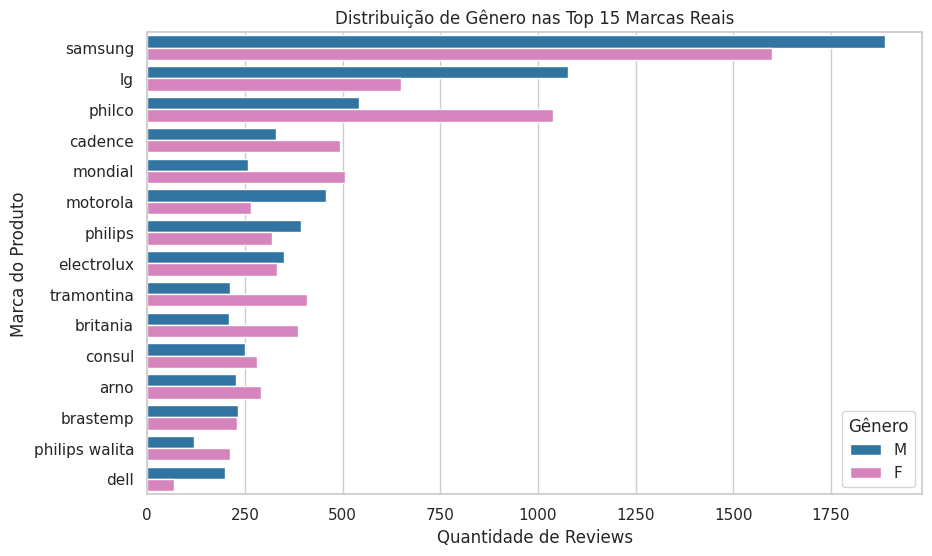

Proporção (%) de público por marca:

reviewer_gender      F      M
product_brand                
mondial          66.19  33.81
tramontina       65.76  34.24
philco           65.65  34.35
britania         64.82  35.18
philips walita   64.05  35.95
cadence          59.95  40.05
arno             56.15  43.85
consul           52.73  47.27
brastemp         49.89  50.11
electrolux       48.83  51.17
samsung          45.84  54.16
philips          44.73  55.27
lg               37.62  62.38
motorola         36.79  63.21
dell             25.56  74.44


In [147]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_top_brands, 
    y='product_brand', 
    hue='reviewer_gender', 
    palette=cores_genero, 
    order=top_brands
)
plt.title(f'Distribuição de Gênero nas Top {N_BRANDS} Marcas Reais')
plt.xlabel('Quantidade de Reviews')
plt.ylabel('Marca do Produto')
plt.legend(title='Gênero')
plt.show()

# Prova estatística: Tabela de proporção
cross_brand = pd.crosstab(df_top_brands['product_brand'], df_top_brands['reviewer_gender'], normalize='index') * 100
print("Proporção (%) de público por marca:\n")
print(cross_brand.round(2).sort_values(by='F', ascending=False))

## Q2: Gênero vs. Categorias

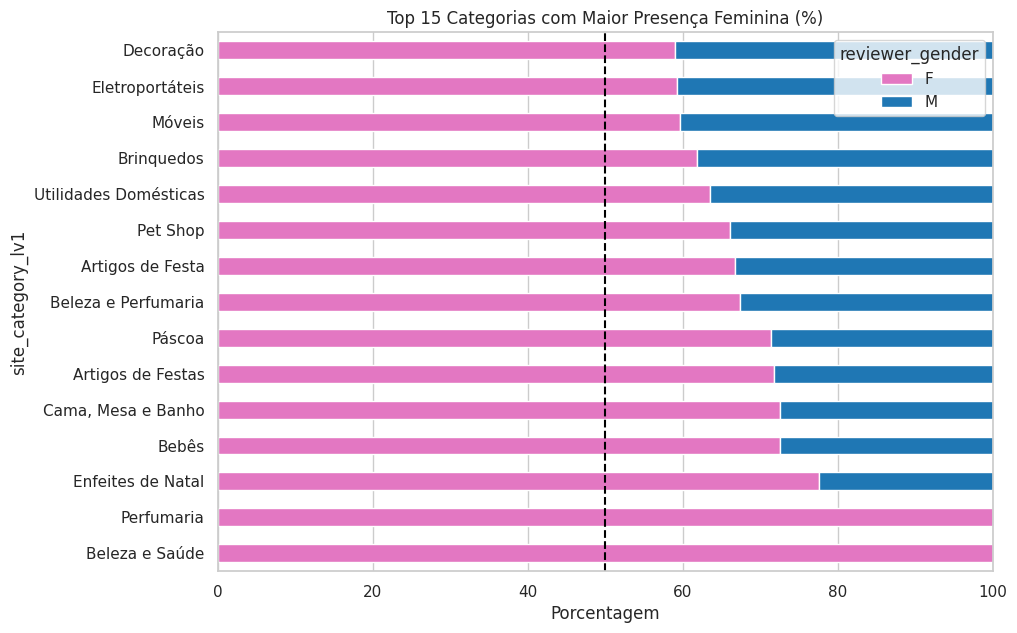

In [148]:
# Proporção de gênero por categoria
cat_gender_dist = pd.crosstab(df_eda['site_category_lv1'], df_eda['reviewer_gender'], normalize='index') * 100
cat_gender_dist = cat_gender_dist.sort_values(by='F', ascending=False).head(15)

cat_gender_dist.plot(kind='barh', stacked=True, figsize=(10, 7), color=cores_genero)
plt.title('Top 15 Categorias com Maior Presença Feminina (%)')
plt.xlabel('Porcentagem')
plt.axvline(50, color='black', linestyle='--') # Linha de equilíbrio
plt.show()

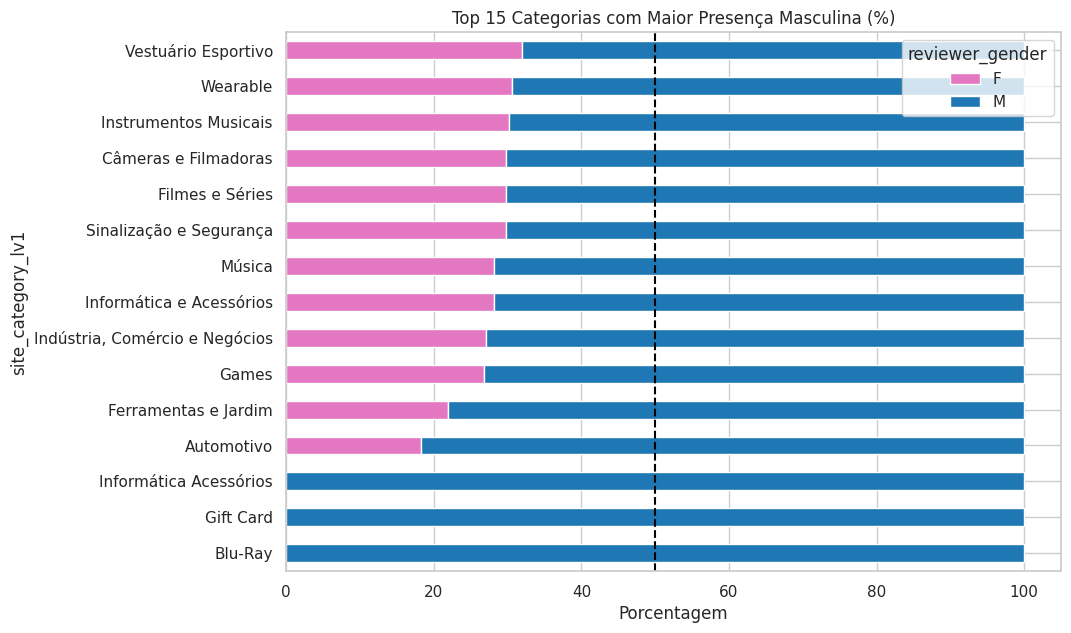

In [149]:
# Proporção de gênero por categoria
cat_gender_dist = pd.crosstab(df_eda['site_category_lv1'], df_eda['reviewer_gender'], normalize='index') * 100
cat_gender_dist = cat_gender_dist.sort_values(by='M', ascending=False).head(15)

cat_gender_dist.plot(kind='barh', stacked=True, figsize=(10, 7), color=cores_genero)
plt.title('Top 15 Categorias com Maior Presença Masculina (%)')
plt.xlabel('Porcentagem')
plt.axvline(50, color='black', linestyle='--') # Linha de equilíbrio
plt.show()

## Q3: Gênero vs. Avaliação

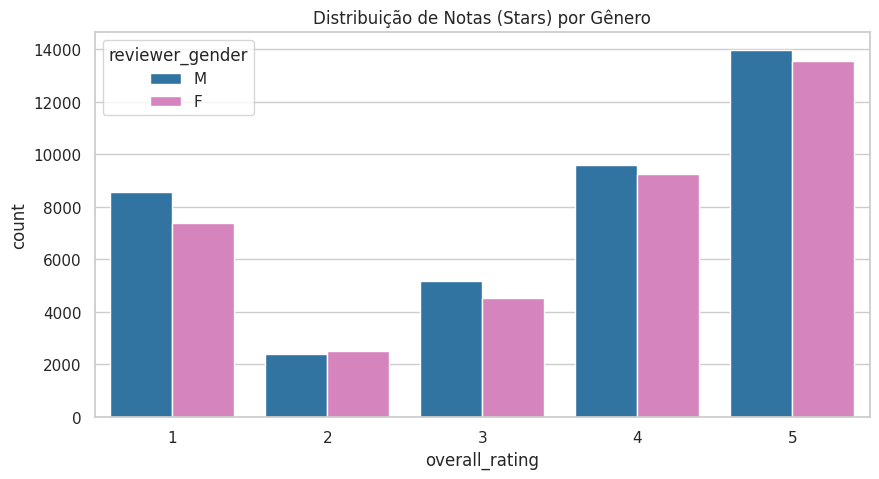

reviewer_gender
F    3.513922
M    3.454948
Name: overall_rating, dtype: float64


In [150]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_train, x='overall_rating', hue='reviewer_gender', palette=cores_genero)
plt.title('Distribuição de Notas (Stars) por Gênero')
plt.show()

# Médias exatas
print(df_train.groupby('reviewer_gender')['overall_rating'].mean())

## Q4: Diferença estatística no tamanho das mensagens

**Existe diferença na extensão dos textos entre gêneros?**

In [11]:
median_m = df_eda[df_eda['reviewer_gender'] == 'M']['word_count'].median()
median_f = df_eda[df_eda['reviewer_gender'] == 'F']['word_count'].median()

print(f"Mediana de palavras - Masculino: {median_m} | Feminino: {median_f}")

Mediana de palavras - Masculino: 19.0 | Feminino: 18.0


Visualização da densidade

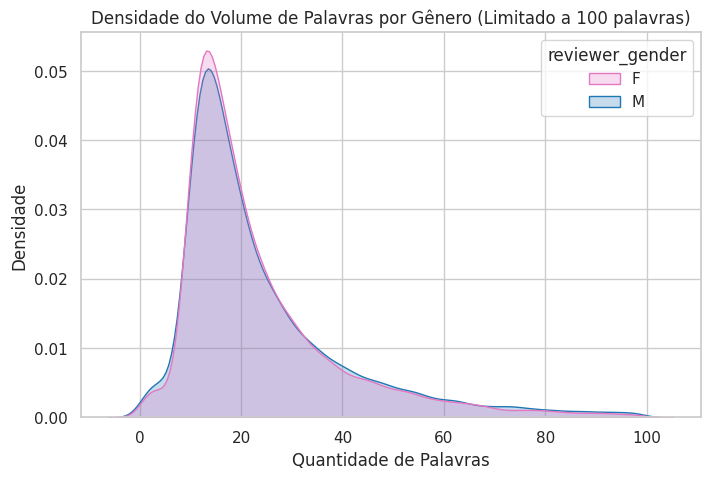

In [ ]:
# (Limitamos a 100 palavras para o gráfico não achatar com outliers absurdos)
W_LIM = 100
plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=df_eda[df_eda['word_count'] < W_LIM], 
    x='word_count', 
    hue='reviewer_gender', 
    fill=True, 
    common_norm=False,
    palette=cores_genero
)
plt.title(f'Densidade do Volume de Palavras por Gênero (Limitado a {W_LIM} palavras)')
plt.xlabel('Quantidade de Palavras')
plt.ylabel('Densidade')
plt.show()

Usando Teste estatístico não-paramétrico de Mann-Whitney U (pois o tamanho de texto raramente segue uma distribuição normal).

In [153]:
stat, p_value = mannwhitneyu(
    df_eda[df_eda['reviewer_gender'] == 'M']['word_count'],
    df_eda[df_eda['reviewer_gender'] == 'F']['word_count'],
    alternative='two-sided'
)
print(f"P-valor do teste estatístico: {p_value:.5e}")

P-valor do teste estatístico: 2.13676e-07


## Conclusões Preliminares Q1 - Q4:
1. Q1: A marca do produto possui correlação com o gênero? Sim, aparentemente, há uma correlação.
2. Q2: Apresenta uma forte correlação
3. Q3: Não apresenta correlação
4. Q4: Como p < 0.5, posso dizer que sim, há uma diferença estatisticamente relevante entre a distribuição de wordcount por gênero

## Q5: Gênero X Recomendações

In [154]:
# Filtramos apenas as notas 3 e 4 (a "zona cinzenta" mencionada no artigo)
df_mid_ratings = df_eda[df_eda['overall_rating'].isin([3, 4])].copy()

# Calculamos a proporção
q5_crosstab = pd.crosstab(df_mid_ratings['reviewer_gender'], df_mid_ratings['recommend_to_a_friend'], normalize='index') * 100

print(q5_crosstab)

recommend_to_a_friend        No        Yes
reviewer_gender                           
F                      4.513788  95.486212
M                      5.220802  94.779198


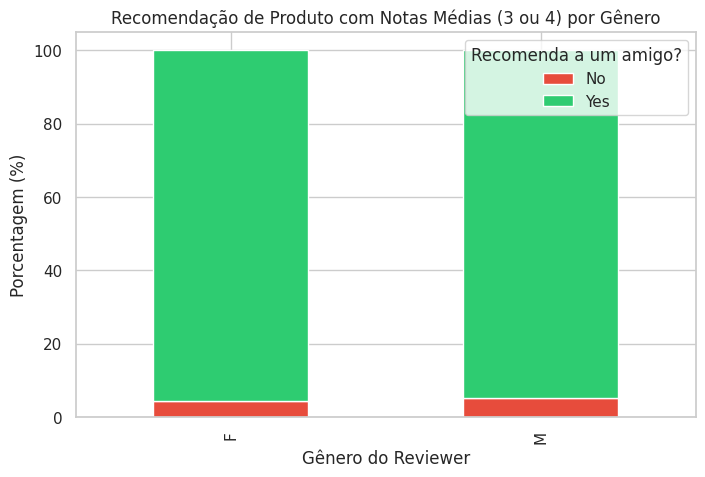

In [155]:
q5_crosstab.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#e74c3c', '#2ecc71'])
plt.title('Recomendação de Produto com Notas Médias (3 ou 4) por Gênero')
plt.ylabel('Porcentagem (%)')
plt.xlabel('Gênero do Reviewer')
plt.legend(title='Recomenda a um amigo?', loc='upper right')
plt.show()

## Q6: Uso de caracteres repetidos e pontuação excessiva (Análise Estilométrica)

Calculando as proporções independentes do tamanho do texto:

In [69]:
# Caixa Alta (palavras inteiras com 2+ letras maiúsculas)
df_eda['upper_count'] = df_eda['full_text'].apply(lambda x: len(re.findall(r'\b[A-ZÀ-Ú]{2,}\b', str(x))))
# Pontuações Múltiplas (ex: !!, ???, ...)
df_eda['multipunct_count'] = df_eda['full_text'].apply(lambda x: len(re.findall(r'[!?\.]{2,}', str(x).lower())))
# Palavras Alongadas (ex: oiii, ameeeei - letra repetida 3+ vezes)
df_eda['repeated_char_count'] = df_eda['review_title'].apply(lambda x: len(re.findall(r'([a-zA-ZÀ-Úà-ú])\1{2,}', str(x))))

# (+1 no denominador para evitar erro matemático de divisão por zero)
df_eda['upper_ratio'] = df_eda['upper_count'] / (df_eda['word_count'] + 1)
df_eda['multipunct_ratio'] = df_eda['multipunct_count'] / (df_eda['word_count'] + 1)
df_eda['repeated_char_ratio'] = df_eda['repeated_char_count'] / (len(df_eda['review_title']) + 1)

Visualização das Estilometrias:

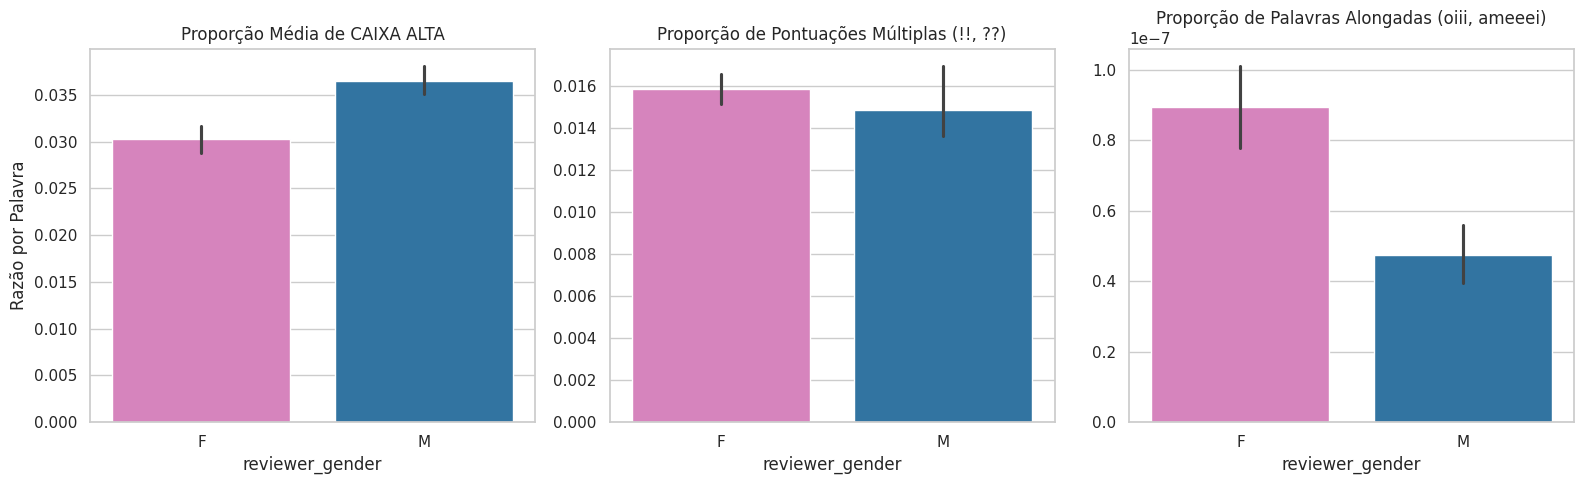

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfico A: Caixa Alta
sns.barplot(data=df_eda, x='reviewer_gender', hue='reviewer_gender', y='upper_ratio', ax=axes[0], palette=cores_genero)
axes[0].set_title('Proporção Média de CAIXA ALTA')
axes[0].set_ylabel('Razão por Palavra')

# Gráfico B: Pontuações Múltiplas
sns.barplot(data=df_eda, x='reviewer_gender', hue='reviewer_gender', y='multipunct_ratio', ax=axes[1], palette=cores_genero)
axes[1].set_title('Proporção de Pontuações Múltiplas (!!, ??)')
axes[1].set_ylabel('') # Ocultado para manter o design limpo

# Gráfico C: Alongamento de Palavras
sns.barplot(data=df_eda, x='reviewer_gender', hue='reviewer_gender', y='repeated_char_ratio', ax=axes[2], palette=cores_genero)
axes[2].set_title('Proporção de Palavras Alongadas (oiii, ameeei)')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

## Q7: Variação no volume de reviews ao longo do tempo

In [158]:
# Converte a coluna para datetime
df_eda['date'] = pd.to_datetime(df_eda['submission_date'])

# Agrupa por semana para o gráfico não ficar muito ruidoso
df_eda['week'] = df_eda['date'].dt.to_period('W').apply(lambda r: r.start_time)

# Conta os reviews por semana e por gênero
timeline = df_eda.groupby(['week', 'reviewer_gender']).size().reset_index(name='count')

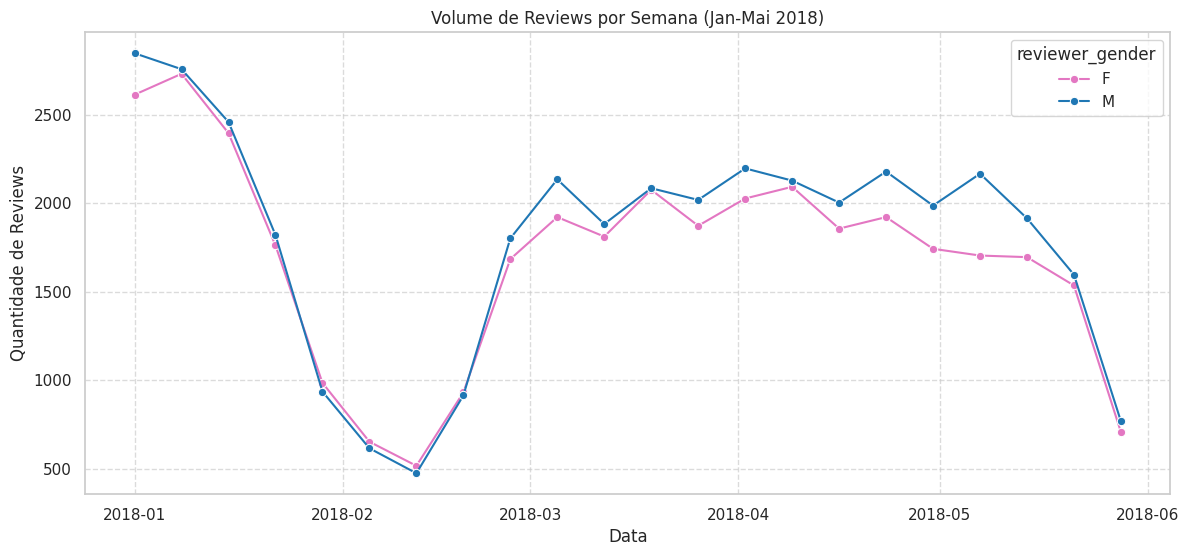

In [159]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=timeline, x='week', y='count', hue='reviewer_gender', palette=cores_genero, marker='o')
plt.title('Volume de Reviews por Semana (Jan-Mai 2018)')
plt.ylabel('Quantidade de Reviews')
plt.xlabel('Data')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Q8: Distribuição de Idade por Gênero

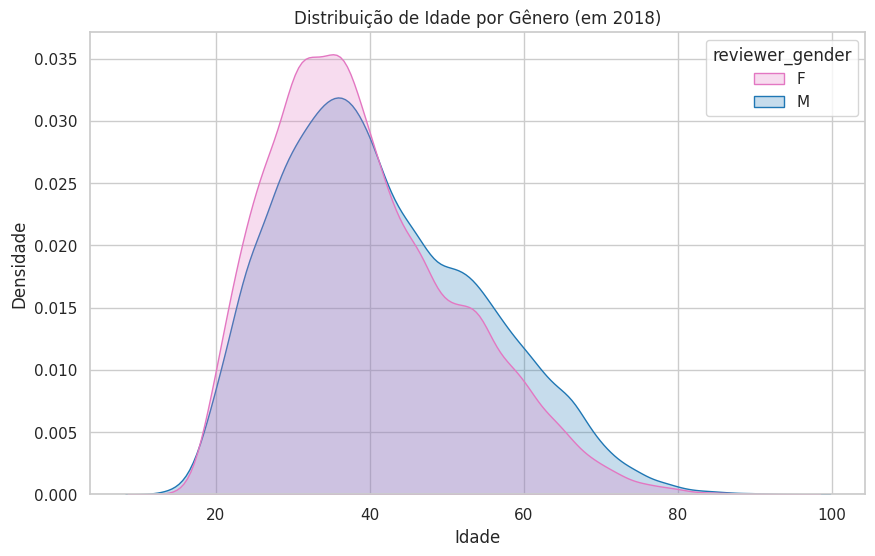

                   count       mean        std   min   25%   50%   75%   max
reviewer_gender                                                             
F                36619.0  39.168874  12.170263  13.0  30.0  37.0  47.0  94.0
M                39016.0  41.375077  13.137570  13.0  31.0  39.0  51.0  95.0


In [160]:
# Filtra anos de nascimento razoáveis (entre 1920 e 2005)
df_age = df_eda[(df_eda['reviewer_birth_year'] > 1920) & (df_eda['reviewer_birth_year'] <= 2005)].copy()

# Calcula a idade em 2018
df_age['age'] = 2018 - df_age['reviewer_birth_year']

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_age, x='age', hue='reviewer_gender', fill=True, common_norm=False, palette=cores_genero)
plt.title('Distribuição de Idade por Gênero (em 2018)')
plt.xlabel('Idade')
plt.ylabel('Densidade')
plt.show()

print(df_age.groupby('reviewer_gender')['age'].describe())

## Resultados Q[5-8]:
- Q5: A diferença entre homens e mulheres ao recomendar um produto com nota média é ínfima (94,8% vs 95,5%) => Ambos tendem a recomendar. coluna recommend_to_a_friend pode ser descartada.
- Q6: Mulheres usam múltiplas pontuações (17,4% vs 15,2%) e letras repetidas (1,7% vs 1,4%) com um pouco mais de frequência. => Exige etapa de pre-processamento.
- Q7: A ausência de picos anômalos ou inversões de proporção entre os meses indica que o comportamento temporal é estável. => A coluna submission_date pode ser descartada.
- Q8: Os homens no dataset são, em média, 2 anos mais velhos que as mulheres (mediana de 39 vs 37). => A coluna reviewer_birth_year é um atributo secundário válido.

### Perguntas associadas a Heurística do Artigo - Módulos de dicionários:
- Q9: Quais são os termos mais discriminativos (Dicionário Latente) por gênero? => Construir diciońario
- Q10: Existe diferença na distribuição do volume de Classes Gramaticais (POS Tags)? (O artigo buscou a flexão do adjetivo.)

## Q9: Quais são os termos mais discriminativos por gênero?

A melhor forma de fazer isso sem ter o viéz de remoção de stopwords ou contagem de palavras brutas é aplicando **Log Odds Ratio com Laplace Smoothing (Suavização de Laplace)**.

Essa métrica calcula a probabilidade de uma palavra aparecer em textos femininos versus masculinos.

Valores altos indicam termos fortemente femininos, e valores negativos indicam termos fortemente masculinos.

Porém, antes de começar essa análise, é necessário fazer uma limpeza no texto base para então ser possível extrair o **Dicionário Latente**

#### A. Limpeza para contagem de palavras limpas (Exclusivo para o Q9):

In [31]:
# Limpeza rápida apenas para contagem de palavras limpas
def clean_for_lexicon(text):
    if not isinstance(text, str):
        return ""
    # remove links e @
    t = re.sub(r'http\S+|www\.\S+|@\w+', '', str(text))
    # remove números e símbolos
    t = re.sub(r'[^a-zA-ZÀ-Úà-ú\s]', '', t) 
    return t.lower()

In [32]:
textos_limpos = df_eda['full_text'].apply(clean_for_lexicon)
print("Vetorizando o vocabulário completo... (Textos limpos)")

# Separamos os corpora
corpus_m = textos_limpos[df_eda['reviewer_gender'] == 'M']
corpus_f = textos_limpos[df_eda['reviewer_gender'] == 'F']

Vetorizando o vocabulário completo... (Textos limpos)


#### B. Implementado o Cálculo do Léxico Discriminatório (Log-Odds)

As stop words tradicionais (como "de", "que", "e", "com", "para") são palavras de altíssima frequência. O objetivo de removê-las geralmente é impedir que elas dominem as estatísticas

Porém, a métrica **Log-Odds Ratio** compara a proporção de uma palavra na classe Feminina contra a classe Masculina. Como a palavra "de" aparece com frequência quase idêntica em textos escritos por homens e por mulheres, a divisão da proporção resulta em um valor muito próximo de 1. O logaritmo de 1 é 0 ($Log(1) = 0$).

Ou seja, a própria fórmula matemática joga as stop words irrelevantes para o meio do gráfico (valor zero), destacando naturalmente apenas as palavras que causam desvio para as extremidades (positivas ou negativas). Nós deixamos a matemática filtrar o que é inútil, em vez de forçar uma lista arbitrária.

In [33]:
nltk.download('stopwords', quiet=True)
stop_words_pt = set(stopwords.words('portuguese'))

In [74]:
LIM_FREQ = 15
vec = CountVectorizer(min_df=LIM_FREQ) # Ignora palavras que aparecem menos de 15 vezes na base
X = vec.fit_transform(textos_limpos)
vocab = vec.get_feature_names_out()

##### Implementando Log-Odds (Porque não Stop-Words?)

Diferente do inglês, a língua portuguesa é fortemente flexionada por gênero. Se você passar a lista padrão de stop words do português no Scikit-Learn, ele vai deletar imediatamente as seguintes palavras:
- a, o, as, os (Artigos que frequentemente precedem produtos focados em um gênero).
- ela, ele, dela, dele (Pronomes pessoais).
- minha, meu, tua, teu (Pronomes possessivos).

In [75]:
# Somatório de frequências por gênero
freq_m = vec.transform(corpus_m).sum(axis=0).A1
freq_f = vec.transform(corpus_f).sum(axis=0).A1

# Suavização de Laplace (para não zerar logaritmos)
prior = 1
total_m = freq_m.sum() + (len(vocab) * prior)
total_f = freq_f.sum() + (len(vocab) * prior)

# Cálculo do Log-Odds (Valores positivos = viés Feminino, Negativos = viés Masculino)
log_odds = np.log((freq_f + prior) / total_f) - np.log((freq_m + prior) / total_m)

print(log_odds.mean())

-0.08367211221612483


In [76]:
df_lexicon = pd.DataFrame({'palavra': vocab, 'log_odds': log_odds})
# Separando os Top 20 de cada
TOP_LEX = 30
top_fem = df_lexicon.nlargest(TOP_LEX, 'log_odds')
top_masc = df_lexicon.nsmallest(TOP_LEX, 'log_odds')

Visualização do Dicionário Léxico:

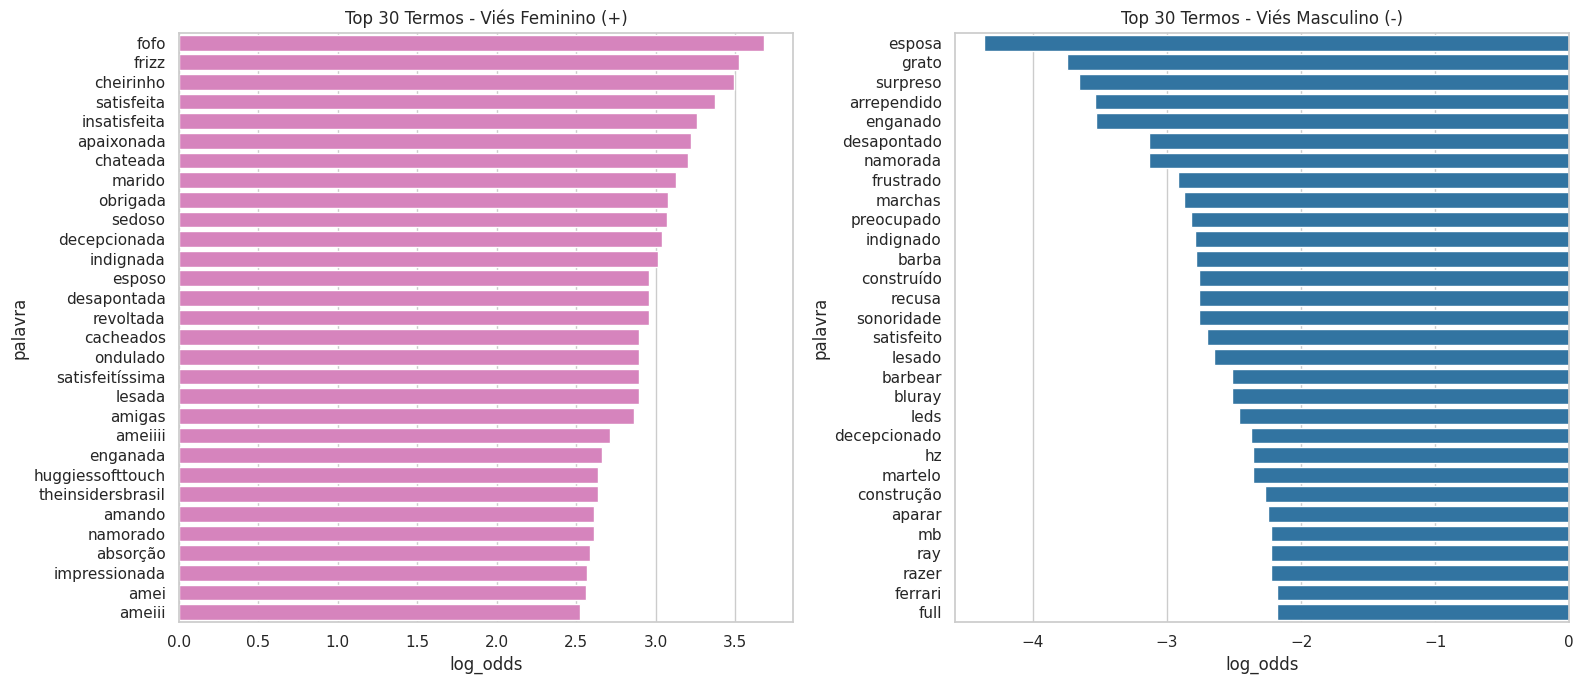

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=top_fem, x='log_odds', y='palavra', ax=axes[0], color=cores_genero['F'])
axes[0].set_title(f'Top {TOP_LEX} Termos - Viés Feminino (+)')

sns.barplot(data=top_masc, x='log_odds', y='palavra', ax=axes[1], color=cores_genero['M'])
axes[1].set_title(f'Top {TOP_LEX} Termos - Viés Masculino (-)')

plt.tight_layout()
plt.show()

In [167]:
# Exportamos para uma lista Python simples para poder ser copiada para o notebook da Fase 2
print("\n[COPIE E COLE NA FASE 2] Top 50 Termos Femininos:")
print(df_lexicon.nlargest(50, 'log_odds')['palavra'].tolist())
print("\n[COPIE E COLE NA FASE 2] Top 50 Termos Masculinos:")
print(df_lexicon.nsmallest(50, 'log_odds')['palavra'].tolist())


[COPIE E COLE NA FASE 2] Top 50 Termos Femininos:
['fofo', 'frizz', 'cheirinho', 'satisfeita', 'insatisfeita', 'apaixonada', 'chateada', 'marido', 'obrigada', 'sedoso', 'decepcionada', 'indignada', 'esposo', 'desapontada', 'revoltada', 'cacheados', 'ondulado', 'satisfeitíssima', 'lesada', 'amigas', 'ameiiii', 'enganada', 'huggiessofttouch', 'theinsidersbrasil', 'amando', 'namorado', 'absorção', 'impressionada', 'amei', 'ameiii', 'arrependida', 'máscara', 'acostumada', 'ameii', 'encantada', 'preocupada', 'condicionador', 'oleoso', 'hidratação', 'hidrata', 'cachos', 'depilador', 'colcha', 'alisa', 'amar', 'gracinha', 'huggies', 'shampoo', 'progressiva', 'casinha']

[COPIE E COLE NA FASE 2] Top 50 Termos Masculinos:
['esposa', 'grato', 'surpreso', 'arrependido', 'enganado', 'desapontado', 'namorada', 'frustrado', 'marchas', 'preocupado', 'indignado', 'barba', 'construído', 'recusa', 'sonoridade', 'satisfeito', 'lesado', 'barbear', 'bluray', 'leds', 'decepcionado', 'hz', 'martelo', 'const

#### Conclusão preliminar do Q9:
- As pessoas utilizam a primeira pessoa do singular e flexionam o adjetivo/particípio para o seu próprio gênero na hora de avaliar.
- A categoria do produto (validado na Q2) reflete diretamente no vocabulário usado no texto.

## Q10: A proporção de uso de certas classes gramaticais varia por gênero?

Como os homens citaram muitas **especificações técnicas (RAM, HD, PC)** e as mulheres focaram em **percepções e ações (Amei, Adorei, Maravilhosa)**:

H: Homens usam mais Substantivos (NOUN) e Nomes Próprios (PROPN), enquanto mulheres usam mais Verbos (VERB) e Adjetivos (ADJ).

#### A. Definindo Extrator Classes Gramaticais - POS Tagging (Apenas para o Q10)

In [61]:
def extract_pos_counts(texts):
    pos_counts = []
    
    text_list = texts.tolist()
    
    for doc in tqdm(nlp.pipe(text_list, batch_size=500), total=len(text_list), desc="Extraindo POS Tags"):
        counts = {'NOUN': 0, 'ADJ': 0, 'VERB': 0, 'PROPN': 0}
        for token in doc:
            if token.pos_ in counts:
                counts[token.pos_] += 1
                
        total_tokens = len(doc) + 1
        pos_counts.append({
            'noun_ratio': counts['NOUN'] / total_tokens,
            'adj_ratio': counts['ADJ'] / total_tokens,
            'verb_ratio': counts['VERB'] / total_tokens,
            'propn_ratio': counts['PROPN'] / total_tokens
        })
    return pd.DataFrame(pos_counts)

In [62]:
print("Iniciando processamento das tags morfológicas em todos os dados...")
df_pos = extract_pos_counts(df_eda['review_title'].fillna(""))
# Concatenando com o df_eda (Reset index garante que as linhas não se embaralhem)
df_eda = pd.concat([df_eda.reset_index(drop=True), df_pos.reset_index(drop=True)], axis=1)

Iniciando processamento das tags morfológicas em todos os dados...


Extraindo POS Tags: 100%|██████████| 76899/76899 [00:14<00:00, 5293.23it/s]


#### B. Vizualizando Distribuição de Classes Gramaticais (POS Tagging)

In [63]:
df_plot = df_eda[['reviewer_gender', 'noun_ratio', 'adj_ratio', 'verb_ratio', 'propn_ratio']].copy()
df_plot.columns = ['Gênero', 'Substantivos', 'Adjetivos', 'Verbos', 'Nomes Próprios']

# "Derrete" o DataFrame para que o Seaborn consiga agrupar lado a lado
pos_melted = df_plot.melt(id_vars='Gênero', var_name='Classe Gramatical', value_name='Razão por Palavra')

plt.figure(figsize=(10, 8))
sns.barplot(
    data=pos_melted, 
    x='Classe Gramatical', 
    y='Razão por Palavra', 
    hue='Gênero', 
    palette=cores_genero
)
plt.title('Proporção Média de Uso Morfossintático no review_title por Gênero')
plt.ylabel('Razão Média por Palavra')
plt.xlabel('')
plt.show()

ValueError: Length mismatch: Expected axis has 13 elements, new values have 5 elements

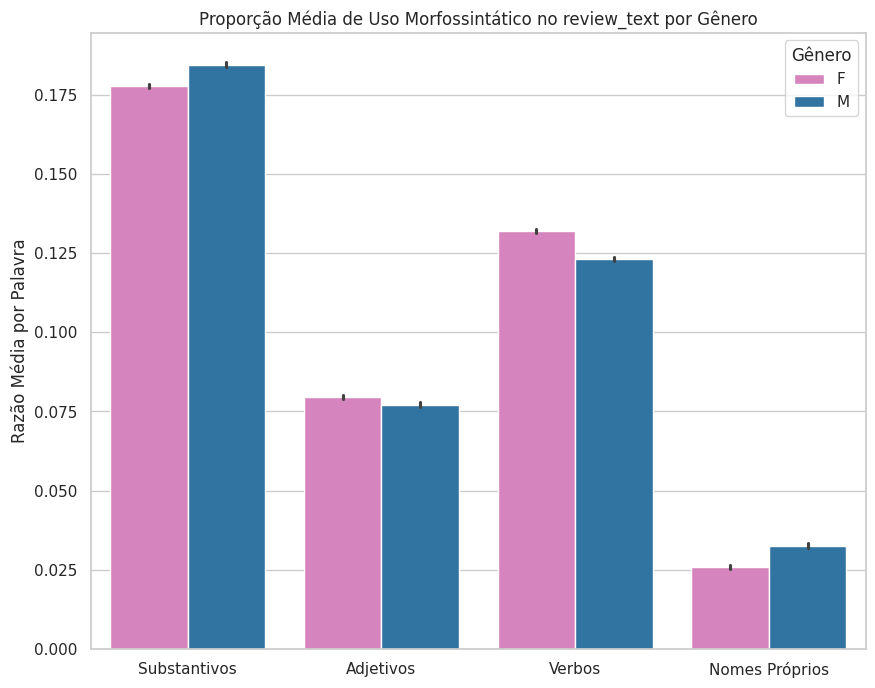

In [55]:
df_plot = df_eda[['reviewer_gender', 'noun_ratio', 'adj_ratio', 'verb_ratio', 'propn_ratio']].copy()
df_plot.columns = ['Gênero', 'Substantivos', 'Adjetivos', 'Verbos', 'Nomes Próprios']

# "Derrete" o DataFrame para que o Seaborn consiga agrupar lado a lado
pos_melted = df_plot.melt(id_vars='Gênero', var_name='Classe Gramatical', value_name='Razão por Palavra')

plt.figure(figsize=(10, 8))
sns.barplot(
    data=pos_melted, 
    x='Classe Gramatical', 
    y='Razão por Palavra', 
    hue='Gênero', 
    palette=cores_genero
)
plt.title('Proporção Média de Uso Morfossintático no review_text por Gênero')
plt.ylabel('Razão Média por Palavra')
plt.xlabel('')
plt.show()

#### Análise dos Resultados de Q10:
- Masculino (noun_ratio e propn_ratio maiores): Foco em objetos, entidades e especificações técnicas (Nomes Próprios e Substantivos). Eles avaliam o que o produto é.
- Feminino (adj_ratio e verb_ratio maiores): Foco em qualidades, percepções e ações (Adjetivos e Verbos). Elas avaliam como se sentiram com o produto ou o serviço.

H: VERDADEIRA!

## Q11: Extração Data-Driven de Stop Words do Domínio

In [191]:
# 1. REAPROVEITAMENTO DA Q9:
# Já temos o df_lexicon, freq_m e freq_f na memória! Não precisamos vetorizar de novo.
df_lexicon['frequencia_total'] = freq_m + freq_f

# 2. ISOLAMENTO DOS TERMOS NEUTROS:
# Filtramos palavras usadas igualmente por homens e mulheres (Log-Odds próximo de 0)
df_neutras = df_lexicon[df_lexicon['log_odds'].between(-0.15, 0.15)].copy()

In [192]:
# Se não removermos a gramática básica, o topo da lista seria "que", "de", "não".
# Usamos o NLTK apenas para filtrar isso e revelar o jargão do e-commerce.
nltk.download('stopwords', quiet=True)
stop_words_pt = set(stopwords.words('portuguese'))

In [196]:
# Mantemos apenas as palavras que NÃO são pronomes/preposições básicas
df_ruido_dominio = df_neutras[~df_neutras['palavra'].isin(stop_words_pt)]

# 4. ORDENAÇÃO:
# Agora ordenamos as palavras neutras do e-commerce pela sua frequência total
candidatas_ruido = df_ruido_dominio.sort_values(by='frequencia_total', ascending=False)
print("Top 30 Stop Words de Domínio (Alta Frequência, Zero Viés):")
display(candidatas_ruido.head(30))

Top 30 Stop Words de Domínio (Alta Frequência, Zero Viés):


,palavra,log_odds,frequencia_total
3853,produto,-0.001257,63219
4123,recomendo,0.125970,16088
1780,entrega,0.118137,15206
1988,excelente,-0.108507,14282
5124,ótimo,0.067436,11993
3974,qualidade,-0.136912,11872
4085,recebi,0.136592,7918
1037,comprei,0.092278,7155
243,americanas,-0.082686,6300
156,ainda,-0.112388,6237


Visualização do Ruído:

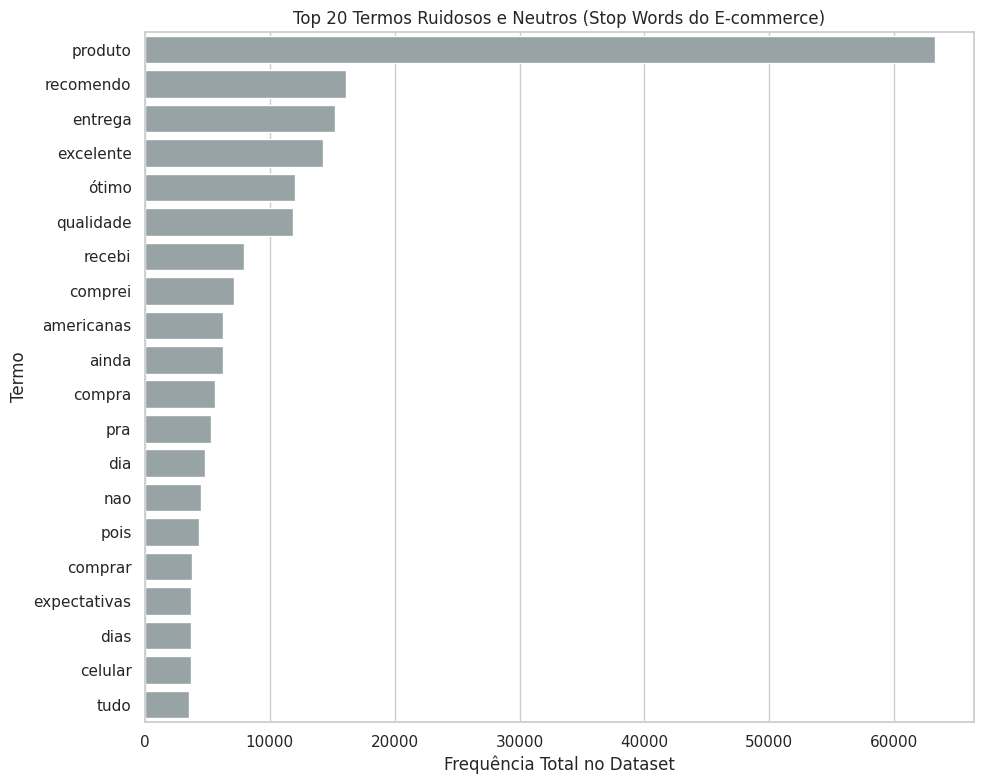

In [197]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=candidatas_ruido.head(20), 
    y='palavra', 
    x='frequencia_total', 
    color='#95a5a6' # Cinzento para representar "informação neutra/ruído"
)
plt.title('Top 20 Termos Ruidosos e Neutros (Stop Words do E-commerce)')
plt.xlabel('Frequência Total no Dataset')
plt.ylabel('Termo')
plt.tight_layout()
plt.show()

In [202]:
# Exportamos a lista final para podermos copiar para o notebook da Fase 1
N_NOISE = 20
domain_stop_words = candidatas_ruido.head(N_NOISE)['palavra'].tolist()
print("\n[COPIE E COLE NA FASE 1] Domain-Specific Stop Words geradas pelos dados:")
print(domain_stop_words)


[COPIE E COLE NA FASE 1] Domain-Specific Stop Words geradas pelos dados:
['produto', 'recomendo', 'entrega', 'excelente', 'ótimo', 'qualidade', 'recebi', 'comprei', 'americanas', 'ainda', 'compra', 'pra', 'dia', 'nao', 'pois', 'comprar', 'expectativas', 'dias', 'celular', 'tudo']


### Conclusões das Análises "Q":
As features mais relevantes para inferir o gênero são:
- A Categoria do Produto (site_category_lv1): A separação de interesse é nítida (ex: Beleza vs. Hardware).
- O Texto Limpo (com Flexões): TF-IDF do texto, mantendo a gramática que indica gênero ("obrigada" vs "obrigado").
- Features de POS-TAG: Relação de Adjetivos, Verbos, Substantivos e Nomes Próprios.
- Estilometria (Q6): Contagem de múltiplas pontuações (!!!), uppercase e letras repetidas (ameeei).
- Idade (reviewer_birth_year): Feature de apoio.
- Tamanho do texto